# Model Complexity vs Predictability — Energy Demand

## Objective

This project explores how prediction performance depends on the **choice of model class**, rather than assuming that more complex models always perform better.

We study:

- A real-world system: **electricity demand (load)**
- Different model classes:
  - Linear models
  - Tree-based models
  - Gradient boosting / neural models

## Core Question

> Does increasing model complexity always improve prediction — or does performance depend on the structure of the underlying system?

---

## Approach

1. Load and preprocess electricity demand data
2. Aggregate to a consistent time resolution (daily)
3. (Later) Add weather features
4. Build lag-based features
5. Compare model performance across:
   - model class
   - prediction horizon

---

## Hypothesis

Prediction performance is not monotonic with model complexity.

Instead:

- Simple systems → linear models suffice  
- Moderately complex systems → tree-based models help  
- Some variability may remain inherently unpredictable  

---

## Dataset

- Source: Kaggle (PJM Energy Consumption)
- Features:
  - Datetime
  - Load (MW)

Weather features will be added separately using Open-Meteo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys


# Add project root to path
sys.path.append(str(Path().resolve().parents[0]))

# Config
from configs.config import *

plt.style.use("seaborn-v0_8")

In [2]:
file_path = RAW_DATA_DIR / "AEP_hourly.csv"

df = pd.read_csv(file_path)

df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [3]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)

df.head()

,Datetime,AEP_MW
0,2004-10-01 01:00:00,12379.0
1,2004-10-01 02:00:00,11935.0
2,2004-10-01 03:00:00,11692.0
3,2004-10-01 04:00:00,11597.0
4,2004-10-01 05:00:00,11681.0


In [4]:
print("Shape:", df.shape)
print("Start:", df["Datetime"].min())
print("End:", df["Datetime"].max())
print("\nMissing values:")
print(df.isna().sum())

Shape: (121273, 2)
Start: 2004-10-01 01:00:00
End: 2018-08-03 00:00:00

Missing values:
Datetime    0
AEP_MW      0
dtype: int64


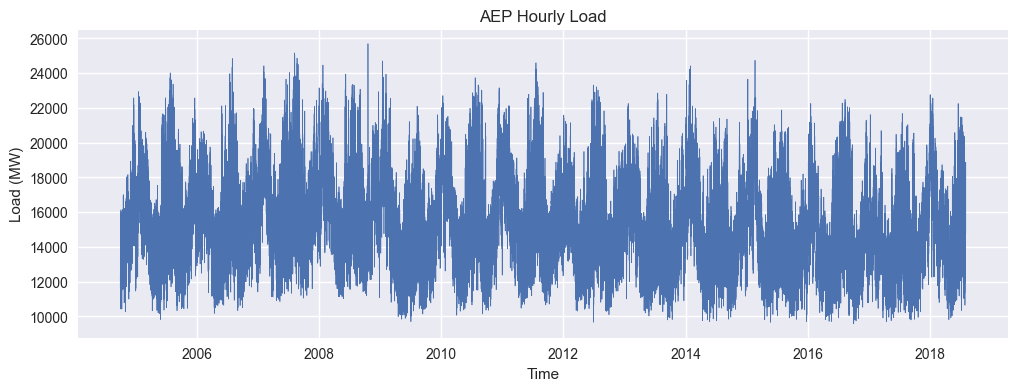

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(df["Datetime"], df["AEP_MW"], linewidth=0.5)
plt.title("AEP Hourly Load")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.show()

In [6]:
df_daily = (
    df.set_index("Datetime")
      .resample("D")
      .mean()
      .reset_index()
)

df_daily.head()

,Datetime,AEP_MW
0,2004-10-01,14284.521739
1,2004-10-02,12999.875000
2,2004-10-03,12227.083333
3,2004-10-04,14309.041667
4,2004-10-05,14439.708333


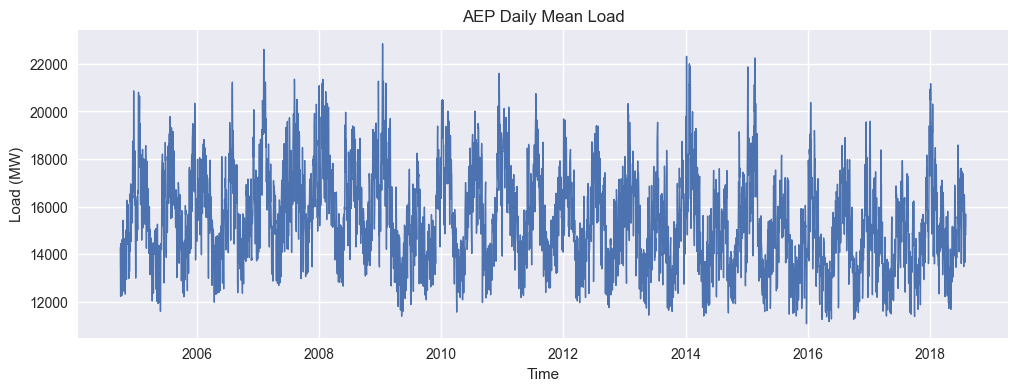

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(df_daily["Datetime"], df_daily["AEP_MW"], linewidth=1.0)
plt.title("AEP Daily Mean Load")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.show()

In [8]:
expected_days = pd.date_range(
    start=df_daily["Datetime"].min(),
    end=df_daily["Datetime"].max(),
    freq="D"
)

missing_days = set(expected_days) - set(df_daily["Datetime"])

print("Number of missing days:", len(missing_days))

Number of missing days: 0


In [9]:
df_daily["AEP_MW"].describe()

count     5055.000000
mean     15499.169905
std       1970.540706
min      11078.041667
25%      14070.020833
50%      15272.458333
75%      16801.229167
max      22847.875000
Name: AEP_MW, dtype: float64

In [10]:
output_path = PROCESSED_DATA_DIR / "aep_daily.parquet"

df_daily.to_parquet(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: /Users/suvo/Projects/model-complexity/data/processed/aep_daily.parquet


In [11]:
start_date = df_daily["Datetime"].min().strftime("%Y-%m-%d")
end_date = df_daily["Datetime"].max().strftime("%Y-%m-%d")

start_date, end_date

('2004-10-01', '2018-08-03')

In [12]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 39.96,   # Columbus, OH
    "longitude": -83.00,
    "start_date": start_date,
    "end_date": end_date,
    "daily": "temperature_2m_mean",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

In [13]:
weather_df = pd.DataFrame({
    "Datetime": pd.to_datetime(data["daily"]["time"]),
    "temp_mean": data["daily"]["temperature_2m_mean"]
})

weather_df.head()

,Datetime,temp_mean
0,2004-10-01,16.0
1,2004-10-02,15.6
2,2004-10-03,10.9
3,2004-10-04,13.0
4,2004-10-05,9.5


In [14]:
df_merged = pd.merge(
    df_daily,
    weather_df,
    on="Datetime",
    how="inner"
)

df_merged.head()

,Datetime,AEP_MW,temp_mean
0,2004-10-01,14284.521739,16.0
1,2004-10-02,12999.875000,15.6
2,2004-10-03,12227.083333,10.9
3,2004-10-04,14309.041667,13.0
4,2004-10-05,14439.708333,9.5


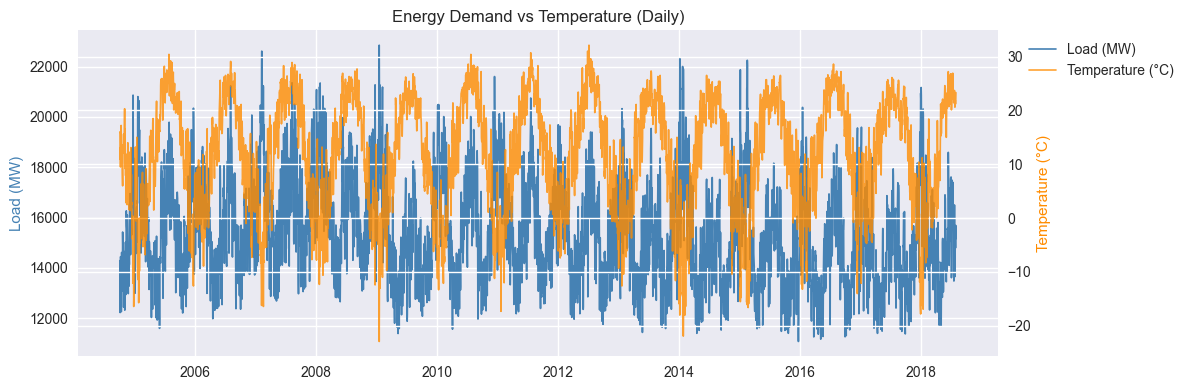

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# Load (left axis)
ax1.plot(
    df_merged["Datetime"],
    df_merged["AEP_MW"],
    color="steelblue",
    linewidth=1.2,
    label="Load (MW)"
)
ax1.set_ylabel("Load (MW)", color="steelblue")

# Temperature (right axis)
ax2 = ax1.twinx()
ax2.plot(
    df_merged["Datetime"],
    df_merged["temp_mean"],
    color="darkorange",
    linewidth=1.2,
    alpha=0.8,
    label="Temperature (°C)"
)
ax2.set_ylabel("Temperature (°C)", color="darkorange")

# Title
plt.title("Energy Demand vs Temperature (Daily)")

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

In [16]:
output_path = PROCESSED_DATA_DIR / "aep_with_weather.csv"
df_merged.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: /Users/suvo/Projects/model-complexity/data/processed/aep_with_weather.csv
